Τεχνητή Νοημοσύνη

1ο Σετ Ασκήσεων

Ονοματεπώνυμο: Ερμιόνη Φώτη

ΑΜ: 2020030081

Ημερομηνία: 24/12/2024



 # ⏩ Άσκηση 4




In [ ]:
import time

EMPTY = '-' # empty cell
BLACK = 'B' # black cell
WHITE = 'W' # white cell

def read_input(filepath):

    with open(filepath, 'r') as f:
        data = f.read().strip()

    size, positions = data.split(':')
    n, m = map(int, size.split('x'))

    # Initialize the grid filled with EMPTY tiles
    grid = [[EMPTY for _ in range(n)] for _ in range(m)]
    row, col = 0, -1
    for ch in positions:
        # Calculate the distance based on the character
        # for example 'a' corresponds to a distance 1, 'b' to 2, 'c' to 3
        distance = ord(ch.lower()) - ord('a') + 1
        for _ in range(distance):
            col += 1 # Move to the next column
            if col == n:
                col = 0
                row += 1 # Move to the next row
            if row >= m:
                break
        if row >= m:
            break
        if 'a' <= ch <= 'z':  # Lowercase -> White tile
            grid[row][col] = WHITE
        elif 'A' <= ch <= 'Z':  # Uppercase -> Black tile
            grid[row][col] = BLACK

    return grid, n, m, data  # Return the grid, size of columns, size of rows and original encoded string

def print_grid(grid):
    for row in grid:
        print(" ".join(row))
    print()

def is_valid(grid, row, col, n, m, color):

    # Temporarily place the color to check if it satisfies all the constraints
    grid[row][col] = color

    # 1 constraint -> Check horizontal constraint: no three consecutive same-colored tiles
    for c in range(max(0, col-2), min(n-2, col+1)):
        if grid[row][c] == grid[row][c+1] == grid[row][c+2] == color:
            grid[row][col] = EMPTY
            return False

    # 2 constraint -> Check vertical constraint: no three consecutive same-colored tiles
    for r in range(max(0, row-2), min(m-2, row+1)):
        if grid[r][col] == grid[r+1][col] == grid[r+2][col] == color:
            grid[row][col] = EMPTY
            return False

    # Count the number of tiles of the specified color in the current row and column
    row_count = sum(1 for c in range(n) if grid[row][c] == color)
    col_count = sum(1 for r in range(m) if grid[r][col] == color)

    # 3 constraint -> The number of tiles of the same color in any row or column has to be equal to half of the total number of columns or rows
    if row_count > n // 2 or col_count > m // 2:
        grid[row][col] = EMPTY
        return False

    grid[row][col] = EMPTY
    return True


def backtracking_solve(grid, row, col, n, m, max_extended_nodes, real_extended_nodes):
    # if the number of extended nodes exceeds the maximum allowed, return false to stop further exploration
    if real_extended_nodes >= max_extended_nodes:
        return False, real_extended_nodes

    # if all rows are filled, this means the puzzle has been solved, so return True
    if row == m or col == n:
        return True, real_extended_nodes

    # Determine the next cell to visit. If we've reached the last column, move to the next row.
    next_row, next_col = (row, col + 1) if col + 1 < n else (row + 1, 0)

    # Skip cells that are already filled with a color
    if grid[row][col] != EMPTY:
        return backtracking_solve(grid, next_row, next_col, n, m, max_extended_nodes, real_extended_nodes)

    # Try to place either a BLACK or WHITE tile in the current empty cell
    for color in (BLACK, WHITE):
        # Check if placing the tile of the current color is valid according to the constraints
        if is_valid(grid, row, col, n, m, color):
            # Place the tile
            grid[row][col] = color
            # Recurse to solve the next cell, incrementing the number of extended nodes
            success, real_extended_nodes = backtracking_solve(grid, next_row, next_col, n, m, max_extended_nodes, real_extended_nodes + 1)
            # If placing this tile leads to a solution, return True
            if success:
                return True, real_extended_nodes

            # If placing the tile doesn't lead to a solution, backtrack by resetting the current cell
            grid[row][col] = EMPTY

    # If no color could lead to a solution, return False and the current extended node count
    return False, real_extended_nodes

def encode_grid(grid, n, m):
    encoded = []
    row, col = 0, 0  # Initialize to start at the first cell
    for i in range(m * n):
        if grid[row][col] == WHITE:
            encoded.append(chr(ord('a')))  # Lowercase 'a' for WHITE
        elif grid[row][col] == BLACK:
            encoded.append(chr(ord('A')))  # Uppercase 'A' for BLACK

        col += 1  # Move to the next column

        # If we have reached the end of the row, reset column and move to the next row
        if col == n:
            col = 0
            row += 1
    # cell(n,m+1) with 'a'
    encoded.append('a')
    return "".join(encoded)

def solve_puzzle(filepath, max_extended_nodes):
    start_time = time.time()
    grid, n, m, encoded_string = read_input(filepath)
    print(f"Initial String: {encoded_string}")
    print("Initial Grid:")
    print_grid(grid)

    output_file = f"output_{n}x{m}.txt"

    success, real_extended_nodes = backtracking_solve(grid, 0, 0, n, m, max_extended_nodes,0)
    if success:
        print("Solved Grid:")
        print_grid(grid)
        result_string = encode_grid(grid,n,m)
        with open(output_file, 'w') as f:
            f.write(f"{n}x{m}:{result_string}")
        print(f"Result: {n}x{m}:{result_string}")
        print(f"Number of nodes expanded: {real_extended_nodes}")
    else:
        print("No solution found.")
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Execution time: {elapsed_time:.2f} seconds")

if __name__ == "__main__":
    input_file = input("Enter the input filename: ")
    max_extended_nodes = int(input("Enter the maximum number of extended nodes: "))
    solve_puzzle(input_file, max_extended_nodes)


Enter the input filename: input_6x6.txt
Enter the maximum number of extended nodes: 100000
Initial String: 6x6:AAbhbaEca
Initial Grid:
B B - W - -
- - - - - W
- W W - - -
- B - - W W
- - - - - -
- - - - - -

No solution found.
Execution time: 0.00 seconds


Στην άσκηση αυτή, υλοποιήθηκε το παιχνίδι/σπαζοκεφαλιά "Unruly", το οποίο αποτελεί πρόβλημα αναζήτησης με στόχο τη συμπλήρωση ενός πίνακα με άσπρα (W) και μαύρα (B) τετράγωνα, σύμφωνα με τους παρακάτω περιορισμούς:

*   Δεν πρέπει να υπάρχουν τρία συνεχόμενα τετράγωνα χρωματισμένα στην ίδια στήλη ή στην ίδια γραμμή.
*   Ο αριθμός των άσπρων και μάυρων τετραγώνων σε κάθε στήλη ή σε κάθε γραμμή πρέπει να είναι ίσος και να αντιστοιχεί στον μισό του συνολικού αριθμού τετραγώνων για την συγκεκριμένη στήλη ή γραμμή αντίστοιχα.

Χρησιμοποιήσαμε για την υλοποίηση του συγκεκριμένου προβλήματος την συστηματική μέθοδο αναζήτησης backtracking μαζί με διάσχιση DFS(Depth Fisrt Search).

Παρακάτω ακολουθεί αναλυτικότερη εξήγηση των συναρτήσεων που χρησιμοποιήθηκαν για την συγκεκριμένη υλοποίηση.

`read_input(filepath)`

 Διαβάζει το αρχείο εισόδου και κατασκευάζει το αρχικό grid, ο οποίος είναι ένας δισδιάστατος πίνακας n(columns) x m(rows). Τοποθετούνται άσπρα (W) και μαύρα (B) τετράγωνα βάσει της αρχικής συμβολοσειράς και τα κενά τετράγωνα αναπαριστώνται με '-'.

 ---

`print_grid(grid)`

Eκτυπώνει τον πίνακα με τα χρωματισμένα και κενά κελιά να διαχωρίζονται με κενά.

---

`is_valid(grid, row, col, n, m, color)`

Ελέγχει αν η τοποθέτηση ενός χρωματισμένου τετραγώνου (λευκού ή μαύρου) είναι έγκυρη, σύμφωνα με τρεις περιορισμούς: α) δεν πρέπει να υπάρχουν τρία συνεχόμενα ίδια χρώματα στην ίδια γραμμή ή στήλη, β) ο αριθμός των χρωματισμένων τετραγώνων σε κάθε γραμμή και στήλη δεν πρέπει να υπερβαίνει το μισό του μεγέθους τους.

---

`backtracking_solve(grid, row, col, n, m, max_extended_nodes, real_extended_nodes)`

  Υλοποιεί το backtracking μαζί με διάσχιση dfs. Η συνάρτηση δοκιμάζει να τοποθετήσει είτε μάυρο είτε άσπρο στο τρέχον κελί και ελέγχει μέσω της συνάρτησης is_valid αν η τοποθέτηση είναι έγκυρη. Αν είναι έγκυρη τοποθετεί το χρώμα στο κελί και καλείται αναδρομικά. Αν η αναδρομική κλήση επιστρέψει false, το οποίο σημαίνει ότι η τοποθέτηση του χρώματος δεν οδηγεί σε λύση, επαναφέρει το κελί στην αρχική του κατάσταση. Σταματά την αναζήτηση αν ξεπεραστεί το μέγιστο επιτρεπτό πλήθος επεκτάσεων (ανοίγματος κόμβων) ή αν βρει λύση



---


`encode_grid(grid, n, m)`

Κωδικοποιεί την λύση του πίνακα(grid) σε συμβολοσειρά. Για κάθε κελί, αν είναι άσπρο το κωδικοποιεί ως 'a', ενώ αν είναι μαύρο το κωδικοποιεί ως 'Α'.Στο τέλος προστίθεται ένα επιπλέον 'a' για να συμβολίσει την θέση στο κελί (n,m+1).

---

`solve_puzzle(filepath, max_extended_nodes)`

Διαβάζει το αρχείο εισόδου μέσω της read_input και καλεί την dfs_solve, η οποία προσπαθεί να λύσει το παιχνίδι. Αν το παιχνίδι έχει λύσει και δεν έχει ξεπεραστεί ο μέγιστος αριθμός κόμβων για επέκταση, αποθηκεύει την λύση σε μορφή συμβολοσειράς σε ένα αρχέιο εξόδου. Σε εναλλακτική περίπτωση, εκτυπώνει μήνυμα σφάλματος. Επιπλέον, μετράει τον χρόνο σε seconds που χρειάστηκε για την έυρεση λύσης.


---

`main`

Ζητάει από τον χρήστη να εισάγει το αρχείο εισόδου, το οποίο περιλαμβάνει την αρχική συμβολοσειρά και τον μέγιστο αριθμό των κόμβων που μπορούν να επεκταθούν. Καλεί την solve_puzzle με τα παραπάνω ορίσματα.


---



Δοκιμάσαμε να τρέξουμε το πρόγραμμα για τα παρακάτω αρχεία εισόδου. Μετά την δημιουργία κάθε αρχείου εισόδου φαίνονται screenshots με τα αποτελέσματα που προκύπτουν για το καθένα. Οι λύσεις επιβεβαιώθηκαν και μέσω της εφαρμογής <a href="http://www.chiark.greenend.org.uk/~sgtatham/puzzles/js/unruly.html" target="_blank">
    Unruly</a> που μας δόθηκε στην εκφώνηση.


In [2]:
%%file input_8x8.txt
8x8:bceadEDgCcAgCcabBi

Writing input_8x8.txt


**Screenshot for input_8x8.txt**

<img src="https://drive.google.com/uc?id=1SlB7d92kW6ZP69hXRR3nn_uRhQ98rZiL" alt="Google Drive Image" width="500" height="400">

Παρακάτω, για επιβεβαίωση παρουσίαζεται ο αρχικός πίνακας και ο τελικός, έτσι όπως προκύπτει από την εφαρμογή για το συγκεκριμένο input_file.


<div style="display: flex; justify-content: space-between; align-items: left;">
  <figure>
    <img src="https://drive.google.com/uc?id=1tbvWNfof11tTb5byVQU5LPrLr4qBn874" width="150" height="150">
    <figcaption>Initial Grid</figcaption>
  </figure>
  <figure>
    <img src="https://drive.google.com/uc?id=1O-Km-CrEWvgf3-nsdxjeWxtpKQ6mviAp" width="150" height="150">
    <figcaption>Solved Grid</figcaption>
  </figure>
</div>







In [3]:
%%file input_6x6.txt
6x6:AAbhbaEca

Writing input_6x6.txt


**Screenshot for input_6x6.txt**

<img src="https://drive.google.com/uc?id=1maxg5cqi1lPkjT4YpvSyXdqxpAlrWTxA" width="300" height="300">


In [4]:
%%file input_10x10.txt
10x10:CBQDAHDaabaCfEacbGJdbaBcbaB

Writing input_10x10.txt


**Screenshot fot input_10x10.txt**

<img src="https://drive.google.com/uc?id=1SpwRCgwQzmd9QrW_F8ecM3r1n9epIqbI" height="500"
width="800">


In [41]:
%%file input_8x6.txt
8x6:aaCdcIcAdeDHb

Writing input_8x6.txt


**Screenshot fot input_8x6.txt**

<img src="https://drive.google.com/uc?id=1QSSowk-GPBkwwoFDbFwZ6FQMuVDzw0qT" height="400" width="400">


In [40]:
%%file input_6x8.txt
6x8:aCcCefdabcCeh

Writing input_6x8.txt


**Screenshot for input_6x8.txt**

<img src="https://drive.google.com/uc?export=view&id=1jwNaU_6V8dLVfs-DSnXidptuJ5PvcoTQ" width="400" height="400">


# ⏩ Άσκηση 4 - Bonus

In [43]:
import time

EMPTY = '-'  # empty cell
BLACK = 'B'  # black cell
WHITE = 'W'  # white cell

def read_input(filepath):
    with open(filepath, 'r') as f:
        data = f.read().strip()

    size, positions = data.split(':')
    n, m = map(int, size.split('x'))

    # Initialize the grid filled with EMPTY tiles
    grid = [[EMPTY for _ in range(n)] for _ in range(m)]
    row, col = 0, -1
    for ch in positions:
        # Calculate the distance based on the character
        distance = ord(ch.lower()) - ord('a') + 1
        for _ in range(distance):
            col += 1  # Move to the next column
            if col == n:
                col = 0
                row += 1  # Move to the next row
            if row >= m:
                break
        if row >= m:
            break
        if 'a' <= ch <= 'z':  # Lowercase -> White tile
            grid[row][col] = WHITE
        elif 'A' <= ch <= 'Z':  # Uppercase -> Black tile
            grid[row][col] = BLACK

    return grid, n, m, data

def print_grid(grid):
    for row in grid:
        print(" ".join(row))
    print()

def is_valid(grid, row, col, n, m, color):
    # Temporarily place the color to check if it satisfies all the constraints
    grid[row][col] = color

    # 1 constraint -> Check horizontal constraint: no three consecutive same-colored tiles
    for c in range(max(0, col-2), min(n-2, col+1)):
        if grid[row][c] == grid[row][c+1] == grid[row][c+2] == color:
            grid[row][col] = EMPTY
            return False

    # 2 constraint -> Check vertical constraint: no three consecutive same-colored tiles
    for r in range(max(0, row-2), min(m-2, row+1)):
        if grid[r][col] == grid[r+1][col] == grid[r+2][col] == color:
            grid[row][col] = EMPTY
            return False

    # Count the number of tiles of the specified color in the current row and column
    row_count = sum(1 for c in range(n) if grid[row][c] == color)
    col_count = sum(1 for r in range(m) if grid[r][col] == color)

    # 3 constraint -> The number of tiles of the same color in any row or column has to be equal to half of the total number of columns or rows
    if row_count > n // 2 or col_count > m // 2:
        grid[row][col] = EMPTY
        return False

    grid[row][col] = EMPTY
    return True

# Get the valid colors for a certain cell
def get_valid_colors(grid, row, col, n, m):
    valid_colors = []
    for color in (BLACK, WHITE):
        if is_valid(grid, row, col, n, m, color):
            valid_colors.append(color)
    return valid_colors

# Get the cell with the fewest valid choices (BLACK or WHITE)
def get_lrv(grid, n, m):
    min_choices = 3  # More than the maximum number of choices (BLACK, WHITE)
    selected_cell = None

    for row in range(m):
        for col in range(n):
            if grid[row][col] == EMPTY:
                valid_colors = get_valid_colors(grid, row, col, n, m)
                num_choices = len(valid_colors)
                if num_choices < min_choices:
                    min_choices = num_choices
                    selected_cell = (row, col)

    return selected_cell

# Get the neighbors of a cell (up, down, left, right)
def get_neighbors(row, col, n, m):
    neighbors = []
    if row > 0:
        neighbors.append((row-1, col))  # up
    if row < m - 1:
        neighbors.append((row+1, col))  # down
    if col > 0:
        neighbors.append((row, col-1))  # left
    if col < n - 1:
        neighbors.append((row, col+1))  # right
    return neighbors

# Get Least Constraining Value (LCV)
def get_lcv(grid, row, col, n, m):
    lcv_scores = {BLACK: 0, WHITE: 0}
    for color in (BLACK, WHITE):
        grid[row][col] = color
        for r, c in get_neighbors(row, col, n, m):
            if grid[r][c] == EMPTY:
                valid_neighbors = get_valid_colors(grid, r, c, n, m)
                lcv_scores[color] += len(valid_neighbors)
        grid[row][col] = EMPTY
    return min(lcv_scores, key=lcv_scores.get)

def solve(grid, n, m, max_extended_nodes, real_extended_nodes):
    # if the number of extended nodes exceeds the maximum allowed, return false to stop further exploration
    if real_extended_nodes >= max_extended_nodes:
        return False, real_extended_nodes

    # if all rows are filled, this means the puzzle has been solved, so return True
    if all(grid[row][col] != EMPTY for row in range(m) for col in range(n)):
        return True, real_extended_nodes

    # Choose the next cell to process: first by MRV, then by LCV
    cell = get_lrv(grid, n, m)
    if not cell:
        return False, real_extended_nodes  # No empty cell found

    row, col = cell

    # Try both BLACK and WHITE for the selected cell, using LCV
    lcv_choice = get_lcv(grid, row, col, n, m)
    for color in (lcv_choice, BLACK if lcv_choice == WHITE else WHITE):
        if is_valid(grid, row, col, n, m, color):
            grid[row][col] = color
            success, real_extended_nodes = solve(grid, n, m, max_extended_nodes, real_extended_nodes + 1)
            if success:
                return True, real_extended_nodes
            grid[row][col] = EMPTY

    return False, real_extended_nodes

def encode_grid(grid, n, m):
    encoded = []
    row, col = 0, 0  # Initialize to start at the first cell
    for i in range(m * n):
        if grid[row][col] == WHITE:
            encoded.append(chr(ord('a')))  # Lowercase 'a' for WHITE
        elif grid[row][col] == BLACK:
            encoded.append(chr(ord('A')))  # Uppercase 'A' for BLACK

        col += 1  # Move to the next column

        # If we have reached the end of the row, reset column and move to the next row
        if col == n:
            col = 0
            row += 1
    # cell(n,m+1) with 'a'
    encoded.append('a')
    return "".join(encoded)

def solve_puzzle(filepath, max_extended_nodes):
    start_time = time.time()
    grid, n, m, encoded_string = read_input(filepath)
    print(f"Initial String: {encoded_string}")
    print("Initial Grid:")
    print_grid(grid)

    output_file = f"output_{n}x{m}_part2.txt"

    success, real_extended_nodes = solve(grid, n, m, max_extended_nodes, 0)
    if success:
        print("Solved Grid:")
        print_grid(grid)
        result_string = encode_grid(grid, n, m)
        with open(output_file, 'w') as f:
            f.write(f"{n}x{m}:{result_string}")
        print(f"Result: {n}x{m}:{result_string}")
        print(f"Number of nodes expanded: {real_extended_nodes}")
    else:
        print("No solution found.")
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Execution time: {elapsed_time:.2f} seconds")

if __name__ == "__main__":
    input_file = input("Enter the input filename: ")
    max_extended_nodes = int(input("Enter the maximum number of extended nodes: "))
    solve_puzzle(input_file, max_extended_nodes)


Enter the input filename: input_8x6.txt
Enter the maximum number of extended nodes: 1000000
Initial String: 8x6:aaCdcIcAdeDHb
Initial Grid:
W W - - B - - -
W - - W - - - -
- - - - B - - W
B - - - W - - -
- W - - - B - -
- - - - - B - W

Solved Grid:
W W B W B W B B
W B B W W B W B
B W W B B W B W
B B W B W W B W
W W B W B B W B
B B W B W B W W

Result: 8x6:aaAaAaAAaAAaaAaAAaaAAaAaAAaAaaAaaaAaAAaAAAaAaAaaa
Number of nodes expanded: 35
Execution time: 0.02 seconds


Για την βελτιστοποίηση του παραπάνω προβλήματος, επιλέξαμε να εφαρμόσουμε αναζήτηση με κάποιο πιο ευριστικό τρόπο και συγκεκριμένα χρησιμοποιώντας **LRV**(Less Remaining Values) και **LCV**(Less Constraining Values).

Για την υλοποίηση αυτή, προστέθηκαν οι εξής συναρτήσεις:

`get_valid_colors(grid, row, col, n, m)`

Επιστρέφει μία λίστα με τα χρώματα (BLACK,WHITE) που επιτρέπεται να τοποθετηθούν σε ένα συγεκριμένο κελί σύμφωνα με τους περιορισμούς που τίθενται από άλλες θέσεις του πίνακα μέσω της συνάρτησης *is_valid*.

---

`get_lrv(grid, n, m)`

Επιστρέφει το κελί του πίνακα που έχει τις λιγότερες έγκυρες επιλογές χρωμάτων (BLACK,WHITE) για τοποθέτηση. Για κάθε κελί που είναι κενό, καλεί τη συνάρτηση *get_valid_colors* για να βρει τα έγκυρα χρώματα και υπολογίζει τον αριθμό των διαθέσιμων επιλογών. Εάν το κελί έχει λιγότερες έγκυρες επιλογές από το τρέχον ελάχιστο, ενημερώνει τη μεταβλητή για το κελί με τις λιγότερες επιλογές και επιστρέφει τη θέση αυτού του κελιού όταν ολοκληρωθεί η αναζήτηση.

---

`get_neighbors(row, col, n, m)`

Επιστρέφει τις θέσεις των γειτονικών κελιών (πάνω,
 κάτω, αριστερά, δεξιά) για ένα συγκεκριμένο κελί.

 ---

`get_lcv(grid, row, col, n, m)`

Επιστρέφει την λιγότερο περιοριστική τιμή (**Least Constraining Value**) για ένα συγκεκριμένο κελί στον πίνακα. Ουσιαστικά, δημιουργεί ένα λεξικό
(*lcv_scores*) που αποθηκεύει τον αριθμό των έγκυρων επιλογών για τα γειτονικά κελιά αντίστοιχα για το κάθε χρωμα (BLACK,WHITE) και επιστρέφει το χρώμα με τον ελάχιστο αριθμό στο lcv_scores, δηλαδή το χρώμα που αφήνει περισσότερες επιλογές για τα γειτονικά κελιά ή αλλιώς το λιγότερο περιοριστικό.

---

`solve(grid, n, m, max_extended_nodes, real_extended_nodes)`

Η συνάρτηση αυτή καλείται αναδρομικά και ελέγχει πρώτα το επόμενο κελί στο οποίο θα γίνει η τοποθέτηση μέσω της συνάρτησης *get_lrv*  και στην συνέχεια επιλέγει το χρώμα το οποίο θα τοποθτήσει μέσω της συνάρτησης *get_lcv* . Η αναδρομή τερματίζεται όταν έχουν γεμίσει όλα τα κελιά ή όταν ο αριθμός των κόμβων που έχουν επεκταθεί έχει ξεπεράσει το μέγιστο όριο.

---

Τρέξαμε το προόγραμμα με τα αρχεία εισόδου που είχαμε δημιουργήσει παραπάνω, για να συγκρίνουμε την αποδοση μεταξύ των δύο (dfs with backtracking - lcv, lrv). Παρακάτω φαίνονται screenshots με τα αποτελέσματα που προκύπτουν για τα διαφορετικά αρχεία εισόδου.

**Screenshot for input_6x6.txt**

  <img src="https://drive.google.com/uc?id=1_kPwDOcchmuOgMxlWHxcz4pdCMx4SwMU" width="350" height="350">


**Screenshot for input_8x8.txt**

  <img src="https://drive.google.com/uc?id=1vQK0_9236l1QNfa4FvX0u-SXEicXc7wr" width="450" height="350">

**Screenshot for input_10x10.txt**

  <img src="https://drive.google.com/uc?id=1nTCQtfany8bjpauTYjeCG2ubz6P9d80v" width="650" height="450">


**Screenshot for input_6x8.txt**

  <img src="https://drive.google.com/uc?id=1Tqvuej1AKFHvmQvqKOigsIYkaLWoXutT" width="300" height="300">


**Screenshot for input_8x6.txt**

  <img src="https://drive.google.com/uc?id=1mx35xVYt4nVrCep2WAbJocISq_ZTRpGw" width="300" height="300">

---

**Σύγκριση των 2 υλοποιήσεων**


Συγκρίνοντας τα αποτελέσματα από τα screenshots που προέκυψαν από τις δύο διαφορετικές υλοποιήσεις, παρατηρούμε ότι η εφαρμογή των στρατηγικών LRV και LCV οδήγησε σε σημαντική μείωση του αριθμού των επεκτεινόμενων κόμβων. Όσον αφορά τον χρόνο εκτέλεσης, η διαφορά δεν είναι σημαντική. Σε ορισμένες περιπτώσεις, ο χρόνος εκτέλεσης μειώθηκε, ενώ σε άλλες αυξήθηκε, αλλά πάντα μόνο για κλάσματα του δευτερολέπτου. Η μεγαλύτερη διαφορά παρατηρήθηκε με το αρχικό εισόδου για πίνακα διαστάσεων 10x10. Συγκεκριμένα, στην πρώτη υλοποίηση με DFS και backtracking, ο αριθμός των επεκτεινόμενων κόμβων ήταν 7328 με χρόνο εκτέλεσης 0,07 δευτερόλεπτα, ενώ με την εφαρμογή των LRV και LCV, ο αριθμός των επεκτεινόμενων κόμβων μειώθηκε σε 77 και ο χρόνος εκτέλεσης σε 0,05 δευτερόλεπτα.

Αυτό είναι και το αναμενόμενο, καθώς οι στρατηγικές LRV και LCV εστιάζουν στην επιλογή περιορισμένων κελιών πρώτα, μειώνοντας έτσι τον αριθμό των περιττών επεκτάσεων. Συγκεκριμένα, η στρατηγική LRV βοηθά στην επιλογή των κελιών με τις λιγότερες διαθέσιμες επιλογές, ενώ η LCV εστιάζει στην επιλογή του χρώματος που προκαλεί τους λιγότερους περιορισμούς για τα γειτονικά κελιά.

# ⏩ Άσκηση 5

In [56]:
import time
import random
import math
import numpy as np


EMPTY = '-' # Empty
BLACK = 'B' # Black
WHITE = 'W' # White

# Same as before
def read_input(filepath):
    with open(filepath, 'r') as f:
        data = f.read().strip()

    size, positions = data.split(':')
    n, m = map(int, size.split('x'))

    grid = [[EMPTY for _ in range(n)] for _ in range(m)]
    row, col = 0, -1
    for ch in positions:
        distance = ord(ch.lower()) - ord('a') + 1
        for _ in range(distance):
            col += 1
            if col == n:
                col = 0
                row += 1
            if row >= m:
                break
        if row >= m:
            break
        if 'a' <= ch <= 'z':
            grid[row][col] = WHITE
        elif 'A' <= ch <= 'Z':
            grid[row][col] = BLACK

    return grid, n, m

# Same as before
def print_grid(grid):
    for row in grid:
        print(" ".join(row))
    print()

# Same as before
def encode_grid(grid, n, m):
    encoded = []
    row, col = 0, 0
    for i in range(m * n):
        if grid[row][col] == WHITE:
            encoded.append(chr(ord('a')))
        elif grid[row][col] == BLACK:
            encoded.append(chr(ord('A')))
        else:
            encoded.append('a')
        col += 1
        if col == n:
            col = 0
            row += 1
    return "".join(encoded)

# Objective function
def objective_function(grid, n, m):
    violations = 0
    # ROWS
    for row in grid:
        black_count = row.count(BLACK)
        white_count = row.count(WHITE)
        violations += abs(black_count - white_count)
        for i in range(n - 2):  # ROWS TRIPLETS
            if row[i] == row[i + 1] == row[i + 2] != EMPTY:
                violations += 1

    # COLUMNS
    for col in range(n):
        black_count = 0
        white_count = 0
        for row in range(m):
            if grid[row][col] == BLACK:
                black_count += 1
            elif grid[row][col] == WHITE:
                white_count += 1
        violations += abs(black_count - white_count)
        for row in range(m - 2):  # COLUMNS TRIPLETS
            if grid[row][col] == grid[row + 1][col] == grid[row + 2][col] != EMPTY:
                violations += 1

    return violations
# Generate a random neighbor grid by changing one empty cell
def random_neighbor(grid, rows, cols, initial_grid):
    new_grid = [row[:] for row in grid]
    while True:
        row = random.randint(0, rows - 1)
        col = random.randint(0, cols - 1)
        if initial_grid[row][col] == EMPTY:
            new_grid[row][col] = random.choice([BLACK, WHITE])
            break
    return new_grid

# Temperature function for simulated annealing
def linear_schedule(step, max_steps,T_initial, T_final):
    return T_initial / (1 + step / max_steps)

# Simulated Annealing algorithm
def simulated_annealing(grid, n, m, max_steps):
    random.seed(int(time.time()))  # Seed random generator
    current_grid = [row[:] for row in grid]
    initial_grid = [row[:] for row in grid]
    current_cost = objective_function(current_grid, n, m)

    best_grid = [row[:] for row in current_grid]
    best_cost = current_cost

    steps = 0
    T_initial = 10
    T_final = 1e-6
    # T = 10000

    while steps < max_steps:
        T = linear_schedule(steps, max_steps, T_initial, T_final)
        # T *= 0.995
        if T < T_final:
            break
        neighbors = random_neighbor(current_grid, n, m, initial_grid)
        neighbor_cost = objective_function(neighbors, n, m)

        # Decide whether to move to the neighbor based on cost and temperature
        if neighbor_cost < current_cost or random.random() < math.exp((current_cost - neighbor_cost) / T):
            current_grid = neighbors
            current_cost = neighbor_cost

        # Update the best solution if needed
        if current_cost < best_cost:
            best_grid = [row[:] for row in current_grid]
            best_cost = current_cost

        if best_cost == 0:  # Solution found
            break

        steps += 1

    return best_grid, best_cost, steps

# Function to evaluate the performance of the algorithm for different number of max_steps
def evaluate_performance(grid, n, m, max_steps_values, num_runs):
    results = []

    for max_steps in max_steps_values:
        success_count = 0
        total_cost = 0
        total_steps = 0
        total_time = 0

        for _ in range(num_runs):
            start_time = time.time()
            best_grid, best_cost, steps = simulated_annealing(grid, n, m, max_steps)
            elapsed_time = time.time() - start_time

            if best_cost == 0:
                success_count += 1

            total_cost += best_cost
            total_steps += steps
            total_time += elapsed_time

        success_rate = (success_count / num_runs) * 100
        avg_cost = total_cost / num_runs
        avg_steps = total_steps / num_runs
        avg_time = total_time / num_runs

        results.append((max_steps, success_rate, avg_cost, avg_steps, avg_time))

    return results

# Function to display evaluation results
def display_results(results):
    print("\nPerformance Summary:")
    print(f"{'Max Steps':<12}{'Success Rate (%)':<20}{'Avg Cost':<12}{'Avg Steps':<12}{'Avg Time (s)':<12}")
    for max_steps, success_rate, avg_cost, avg_steps, avg_time in results:
        print(f"{max_steps:<12}{success_rate:<20.2f}{avg_cost:<12.2f}{avg_steps:<12.2f}{avg_time:<12.2f}")

if __name__ == "__main__":
    input_file = input("Enter the input filename: ")
    max_steps = int(input("Enter the maximum number of steps: "))

    grid, n, m = read_input(input_file)

    print("Initial Grid:")
    print_grid(grid)
    start_time = time.time()
    best_grid, best_cost, steps = simulated_annealing(grid, n, m, max_steps)
    elapsed_time = time.time() - start_time

    print("\nBest Grid Found:")
    for row in best_grid:
        print(" ".join(row))

    encoded_string = encode_grid(best_grid, n, m)
    print(f"Best Solution: {n}x{m}:{encoded_string}")
    print(f"\nViolations in best solution: {best_cost}")
    print(f"Execution Time: {elapsed_time:.2f} seconds")
    print(f"Steps Taken: {steps}")

    # Performance evaluation
    user_input = input("Do you want to evaluate performance? (yes to continue):\n").strip().lower()
    if user_input == "yes":
      print("Evaluating performance...")
      max_steps_values = [5000, 10000, 50000, 100000, 500000]
      num_runs = 50
      results = evaluate_performance(grid, n, m, max_steps_values, num_runs)
      display_results(results)
    else:
      print("Evaluation skipped")

Enter the input filename: input_6x6.txt
Enter the maximum number of steps: 100000
Initial Grid:
B B - W - -
- - - - - W
- W W - - -
- B - - W W
- - - - - -
- - - - - -


Best Grid Found:
B B W W B W
W B B W B W
B W W B W B
B B W B W W
W W B W B B
W W B B W B
Best Solution: 6x6:AAaaAaaAAaAaAaaAaAAAaAaaaaAaAAaaAAaA

Violations in best solution: 0
Execution Time: 3.69 seconds
Steps Taken: 96240
Do you want to evaluate performance? (yes to continue):
yes
Evaluating performance...

Performance Summary:
Max Steps   Success Rate (%)    Avg Cost    Avg Steps   Avg Time (s)
5000        0.00                6.96        5000.00     0.15        
10000       0.00                7.02        10000.00    0.31        
50000       4.00                4.38        48996.72    1.47        
100000      2.00                3.92        99591.52    2.94        
500000      4.00                2.76        496551.44   14.90       


Σε αυτήν την εργασία υλοποιήσαμε το παιχνίδι "Unruly", το οποίο μελετήθηκε και προηγουμένως, αλλά αυτήν την φορά χρησιμοποιήθηκε η μέθοδος προσομειωμένη ανόπτηση για την επίλυση του.

Οι συναρτήσεις read_input, print_grid και encode_grid χρησιμοποιήθηκαν όπως ακιβώς στην άσκηση 4. Επιπλέον, υλοποιήθηκαν οι εξής συναρτήσεις:


`objective_function(grid, n, m)`

Η συνάρτηση υπολογίζει την αντικειμενική συνάρτηση f που χρησιμοποιείται για την αξιολόγηση καταστάσεων σύμφωνα με τον παρακάτω τύπο.

<img src="https://drive.google.com/uc?id=1dF9-KbK-NG5aJAuXTolxhIOtaHL8OB23" alt="Image from Google Drive">

Ουσιαστικά, υπολογίζει και επιστρέφει τον αριθμό παραβιάσεων σύμφωνα με τους δύο βασικούς κανόνες του παιχνιδιού. Πιο συγκεκριμένα, για κάθε γραμμή και κάθε στήλη μετρά τις παραβιάσεις σχετικά με την ισοκατανομή των χρωμάτων και τις τριάδες συνεχόμενων τετραγώνων με το ίδιο χρώμα.

---


`random_neighbor(grid, rows, cols, initial_grid)`

Δημιουργεί έναν αντίγραφο του αρχικού πίνακα και επιλέγει μία τυχαία θέση και την γεμίζει με ένα τυχαίο χρώμα είτε μάυρο είτε άσπρο.

---

`linear_schedule(step, max_steps,T_initial, T_final)`

Υπολογίζει την θερμοκρασία, η οποία μειώνεται γραμμικά με την πρόοδο των βημάτων. Η θερμοκρασία ξεκινά από την αρχική τιμή T_initial και μειώνεται όσο αυξάνεται το βήμα (step), μέχρι να φτάσει την τελική τιμή T_final. Ο τύπος που χρησιμοποιείται είναι:

    T = T_initial / 1 + (step / max_steps)

---


`simulated_annealing(grid, n, m, max_steps)`

Εκτελεί τον αλγόριθμο Simulated Annealing, ο οποίος λειτουργεί λειτουργεί ως εξής: Ξεκινά με έναν τυχαία επιλεγμένο πίνακα και υπολογίζει το κόστος της τρέχουσας διάταξης χρησιμοποιώντας τη συνάρτηση *objective_function*. Στη συνέχεια, εξετάζει τους γείτονες της τρέχουσας λύσης και υπολογίζει το κόστος τους. Ο αλγόριθμος αποφασίζει αν θα προχωρήσει σε έναν γείτονα με βάση το κόστος και τη θερμοκρασία, που μειώνεται σταδιακά με το χρόνο μέσω της συνάρτησης *linear_schedule*. Εάν βρει μια καλύτερη λύση, την αποθηκεύει ως καλύτερη. Η διαδικασία συνεχίζεται έως ότου φτάσει στο μέγιστο αριθμό βημάτων ή βρει την ιδανική λύση (όταν το κόστος γίνει 0) ή η θερμοκρασία πέσει κάτω από την τιμή *T_final*, οπότε ο αλγόριθμος τερματίζει.


---


`evaluate_performance(grid, n, m, max_steps_values, num_runs)`

Aξιολογεί την απόδοση του αλγορίθμου Simulated Annealing για διαφορετικούς αριθμούς μέγιστων βημάτων (max_steps). Για κάθε τιμή max_steps, εκτελεί τον αλγόριθμο 50(*num_runs*) φορές, καταγράφοντας το ποσοστό επιτυχίας (όταν το κόστος είναι 0), το μέσο κόστος, τον μέσο αριθμό βημάτων και το μέσο χρόνο εκτέλεσης.

---

`display_results(results)`

Εκτυπώνει τα αποτελέσματα που επέστρεψε η συνάρτηση *evaluate_performance* σε έναν πίνακα.

---

Παρακάτω παρουσιαζεται screenshot από την εκτέλεση του προγράμματος.

**Screenshot for input_6x6.txt**

 <img src="https://drive.google.com/uc?id=1mQHvS9MUOL46Ame0kws8-y4ahoeCGsZh" >


# ⏩ Άσκηση 5 - Bonus


Processing file: input_10x10.txt

Initial Grid:
- - B - B - - - - -
- - - - - - - - - -
- B - - - B B - - -
- - - - B - - - B W
W - W W - - B - - -
- - W - - - - B W -
- W - W - - - - - -
B - - - - - - - - -
B - - - W - W W - B
- - W - W W - B - -


Best Grid Found:
- - B - B - - W - -
- - - - - - - - - -
- B - - - B B - - -
- - - - B - - - B W
W - W W B - B - - -
- - W - - - - B W -
- W B W - - - - - -
B - - - - - - - - -
B - - - W - W W - B
- - W - W W - B - -
Best Solution: 10x10:aaAaAaaaaaaaaaaaaaaaaAaaaAAaaaaaaaAaaaAaaaaaAaAaaaaaaaaaaAaaaaAaaaaaaaAaaaaaaaaaAaaaaaaaaAaaaaaaaAaa

Violations in best solution: 18
Execution Time: 7.65 seconds
Steps Taken: 100000
Evaluating performance...


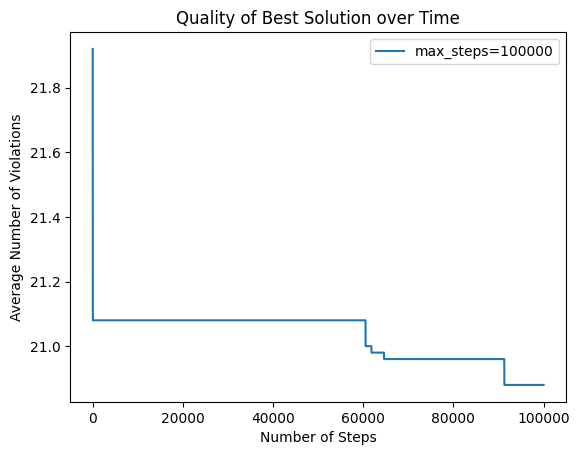


Performance Summary:
Max Steps   Success Rate (%)    Avg Cost    Avg Steps   Avg Time (s)
100000      100.00              20.88       100000.00   6.96        


In [64]:
import time
import random
import math
import numpy as np
import matplotlib.pyplot as plt

EMPTY = '-' # Empty
BLACK = 'B' # Black
WHITE = 'W' # White

# Read input data
def read_input(filepath):
    with open(filepath, 'r') as f:
        data = f.read().strip()

    size, positions = data.split(':')
    n, m = map(int, size.split('x'))

    grid = [[EMPTY for _ in range(n)] for _ in range(m)]
    row, col = 0, -1
    for ch in positions:
        distance = ord(ch.lower()) - ord('a') + 1
        for _ in range(distance):
            col += 1
            if col == n:
                col = 0
                row += 1
            if row >= m:
                break
        if row >= m:
            break
        if 'a' <= ch <= 'z':
            grid[row][col] = WHITE
        elif 'A' <= ch <= 'Z':
            grid[row][col] = BLACK

    return grid, n, m

# Print the grid
def print_grid(grid):
    for row in grid:
        print(" ".join(row))
    print()

# Encode grid to string
def encode_grid(grid, n, m):
    encoded = []
    row, col = 0, 0
    for i in range(m * n):
        if grid[row][col] == WHITE:
            encoded.append(chr(ord('a')))
        elif grid[row][col] == BLACK:
            encoded.append(chr(ord('A')))
        else:
            encoded.append('a')
        col += 1
        if col == n:
            col = 0
            row += 1
    return "".join(encoded)

# Objective function
def objective_function(grid, n, m):
    violations = 0
    # ROWS
    for row in grid:
        black_count = row.count(BLACK)
        white_count = row.count(WHITE)
        violations += abs(black_count - white_count)
        for i in range(n - 2):  # ROWS TRIPLETS
            if row[i] == row[i + 1] == row[i + 2] != EMPTY:
                violations += 1

    # COLUMNS
    for col in range(n):
        black_count = 0
        white_count = 0
        for row in range(m):
            if grid[row][col] == BLACK:
                black_count += 1
            elif grid[row][col] == WHITE:
                white_count += 1
        violations += abs(black_count - white_count)
        for row in range(m - 2):  # COLUMNS TRIPLETS
            if grid[row][col] == grid[row + 1][col] == grid[row + 2][col] != EMPTY:
                violations += 1

    return violations

# Generate a random neighbor grid by changing one empty cell
def random_neighbor(grid, rows, cols, initial_grid):
    new_grid = [row[:] for row in grid]
    while True:
        row = random.randint(0, rows - 1)
        col = random.randint(0, cols - 1)
        if initial_grid[row][col] == EMPTY:
            new_grid[row][col] = random.choice([BLACK, WHITE])
            break
    return new_grid

# Temperature function for simulated annealing
def linear_schedule(step, max_steps, T_initial, T_final):
    return T_initial / (1 + step / max_steps)

# Simulated Annealing algorithm with violations tracking
def simulated_annealing(grid, n, m, max_steps):
    random.seed(int(time.time()))  # Seed random generator
    current_grid = [row[:] for row in grid]
    initial_grid = [row[:] for row in grid]
    current_cost = objective_function(current_grid, n, m)

    best_grid = [row[:] for row in current_grid]
    best_cost = current_cost

    steps = 0
    T_initial = 10
    T_final = 1e-6
    violations_history = []  # Track the number of violations at each step

    while steps < max_steps:
        T = linear_schedule(steps, max_steps, T_initial, T_final)
        #T *= 0.995
        if T < T_final:
           break

        neighbors = random_neighbor(current_grid, n, m, initial_grid)
        neighbor_cost = objective_function(neighbors, n, m)

        # Decide whether to move to the neighbor based on cost and temperature
        if neighbor_cost < current_cost or random.random() < math.exp((current_cost - neighbor_cost) / T):
            current_grid = neighbors
            current_cost = neighbor_cost

        # Update the best solution if needed
        if current_cost < best_cost:
            best_grid = [row[:] for row in current_grid]
            best_cost = current_cost

        violations_history.append(best_cost)  # Record the violations at this step

        if best_cost == 0:  # Solution found
            break

        steps += 1

    return best_grid, best_cost, steps, violations_history

# Function to evaluate the performance of the algorithm for different number of max_steps
def evaluate_performance(grid, n, m, max_steps_values, num_runs):
    all_violations_history = []
    results = []

    for max_steps in max_steps_values:
        total_cost = 0
        total_steps = 0
        total_time = 0
        violations_history_accumulated = []

        for _ in range(num_runs):
            start_time = time.time()
            best_grid, best_cost, steps, violations_history = simulated_annealing(grid, n, m, max_steps)
            elapsed_time = time.time() - start_time

            total_cost += best_cost
            total_steps += steps
            total_time += elapsed_time

            violations_history_accumulated.append(violations_history)

        max_length = max(len(vh) for vh in violations_history_accumulated)

        padded_violations_history = [
            vh + [vh[-1]] * (max_length - len(vh)) if len(vh) < max_length else vh
            for vh in violations_history_accumulated
        ]

        avg_violations_per_step = np.mean(padded_violations_history, axis=0)

        plt.plot(range(len(avg_violations_per_step)), avg_violations_per_step, label=f"max_steps={max_steps}")

        success_rate = (num_runs - (total_cost == 0)) / num_runs * 100
        avg_cost = total_cost / num_runs
        avg_steps = total_steps / num_runs
        avg_time = total_time / num_runs

        results.append((max_steps, success_rate, avg_cost, avg_steps, avg_time))

    plt.xlabel('Number of Steps')
    plt.ylabel('Average Number of Violations')
    plt.title('Quality of Best Solution over Time')
    plt.legend()
    plt.show()

    return results

# Function to display evaluation results
def display_results(results):
    print("\nPerformance Summary:")
    print(f"{'Max Steps':<12}{'Success Rate (%)':<20}{'Avg Cost':<12}{'Avg Steps':<12}{'Avg Time (s)':<12}")
    for max_steps, success_rate, avg_cost, avg_steps, avg_time in results:
        print(f"{max_steps:<12}{success_rate:<20.2f}{avg_cost:<12.2f}{avg_steps:<12.2f}{avg_time:<12.2f}")

if __name__ == "__main__":
    input_file = "input_10x10.txt"
    max_steps = 100000

    print(f"\nProcessing file: {input_file}")
    grid, n, m = read_input(input_file)

    print("\nInitial Grid:")
    print_grid(grid)

    start_time = time.time()
    best_grid, best_cost, steps, violations_history = simulated_annealing(grid, n, m, max_steps)
    elapsed_time = time.time() - start_time

    print("\nBest Grid Found:")
    for row in best_grid:
        print(" ".join(row))

    encoded_string = encode_grid(best_grid, n, m)
    print(f"Best Solution: {n}x{m}:{encoded_string}")
    print(f"\nViolations in best solution: {best_cost}")
    print(f"Execution Time: {elapsed_time:.2f} seconds")
    print(f"Steps Taken: {steps}")

    print("Evaluating performance...")
    max_steps_values = [100000]  # You can add more step values if needed
    num_runs = 50
    results = evaluate_performance(grid, n, m, max_steps_values, num_runs)
    display_results(results)


Σε αυτό το κομμάτι της άσκησης καταγράψαμε την ποιότητα
της τρέχουσας καλύτερης «λύσης» (αριθμός παραβιάσεων) κατά τη διάρκεια της αναζήτησης. Δημιουργήσαμε γραφικές παραστάσεις της μέσης ποιότητας ως προς τον αριθμό των τοπικών βημάτων για ένα μέγιστο αριθμό βημάτων αναζήτησης 100000 για τρία διαφορετικά αρχέια εισόδου.



**Graph for input_6x6.txt**

<img src="https://drive.google.com/uc?export=view&id=1ITImuR9fTfBNoybkG2ljAEF74pbe7k7M" width="400">


**Graph for input_8x8.txt**

<img src="https://drive.google.com/uc?export=view&id=10-8ayC9qOUK7MG0AAfhnCxahiOjeqoRU"  width="400">


**Graph for input_10x10.txt**

<img src="https://drive.google.com/uc?export=view&id=1nzFwY05E44RVNy25JeimsU2EfSBd3Fmk" width="400">


**1.  Πώς βελτιώνεται η ποιότητα ως προς τον
αριθμό των τοπικών βημάτων;**

Στα γραφήματα παρατηρείται ότι ο αριθμός των παραβιάσεων μειώνεται σταδιακά καθώς αυξάνεται ο αριθμός των τοπικών βημάτων. Η καμπύλη εμφανίζει πτωτική πορεία, γεγονός που υποδηλώνει τη συνεχή βελτίωση της ποιότητας της λύσης (δηλαδή, τη μείωση των παραβιάσεων). Η μεγαλύτερη βελτίωση σημειώνεται στα αρχικά βήματα, όπου οι αλλαγές στις καταστάσεις διορθώνουν εύκολα τις περισσότερες παραβιάσεις. Στη συνέχεια, η πρόοδος γίνεται πιο αργή, προσεγγίζοντας σταθεροποίηση.


**2.  Πού παρατηρείται η μεγαλύτερη βελτίωση ή αλλιώς η μεγαλύτερη πρόοδος προς κάποια λύση;**

Η μεγαλύτερη βελτίωση παρατηρείται στα πρώτα στάδια της διαδικασίας. Αυτό οφείλεται στο γεγονός ότι η τυχαία αρχική κατάσταση συνήθως περιέχει πολλές παραβιάσεις, οι οποίες μπορούν να διορθωθούν σχετικά εύκολα στα πρώτα τοπικά βήματα. Με την πρόοδο της αναζήτησης και τη μείωση της θερμοκρασίας , οι αλλαγές στον πίνακα μειώνονται, οδηγώντας σε πιο αργή βελτίωση και σχεδόν σταθεροποίηση.

**3. Υπάρχει ποιοτική διαφορά για διαφορετικά μεγέθη;**
Υπάρχει ποιοτική διφορά για διαφορετικά μεγέθη.
Για μικρότερα μεγέθη (π.χ. 6x6),η βελτίωση είναι ταχύτερη και σημαντικότερη. Ο αριθμός των παραβιάσεων μειώνεται γρήγορα, καθώς οι δυνατές λύσεις είναι πιο περιορισμένες και οι παραβιάσεις μπορούν να διορθωθούν πιο εύκολα.
Αντίθετα, για μεγαλύτερα μεγέθη (π.χ. 10x10), η πρόοδος είναι πιο αργή, και η τελική μείωση των παραβιάσεων είναι μικρότερη. Ο μεγάλος αριθμός πιθανών καταστάσεων και παραβιάσεων καθιστά την εύρεση βέλτιστων λύσεων πιο δύσκολη.
